### Produce metadata figures for the celllevel information

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

from collections import Counter
import seaborn as sns
import scanpy as sc 
import os
import gc

In [2]:
sc._settings.settings._vector_friendly=True

In [7]:
%%time
adata = sc.read_h5ad("../06B_combined_scVI_raw_only.h5ad")
#adata = sc.read_h5ad("../06C_final_adata_for_UCSC.h5ad")
adata

CPU times: user 17.4 s, sys: 1min 1s, total: 1min 19s
Wall time: 1min 33s


AnnData object with n_obs × n_vars = 2275105 × 16115
    obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'le

In [8]:
plots_dir = "metadata_plots/"

In [11]:
%%time 
# create UMAP
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['final_cell_type'], legend_loc = "on data", show=False)
    plt.savefig(plots_dir + "cell_type_UMAP.pdf", bbox_inches="tight")
    plt.show()

CPU times: user 1min 21s, sys: 5.25 s, total: 1min 26s
Wall time: 1min 25s


In [10]:
# create UMAP
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['cm_score'], legend_loc = "on data", show=False)
    plt.savefig(plots_dir + "cm_score_UMAP.pdf", bbox_inches="tight")
    plt.show()

### Produce other UMAP plots (by study)

In [6]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['study'], show=False)
    plt.savefig(plots_dir  + "study_UMAP.pdf", bbox_inches="tight")

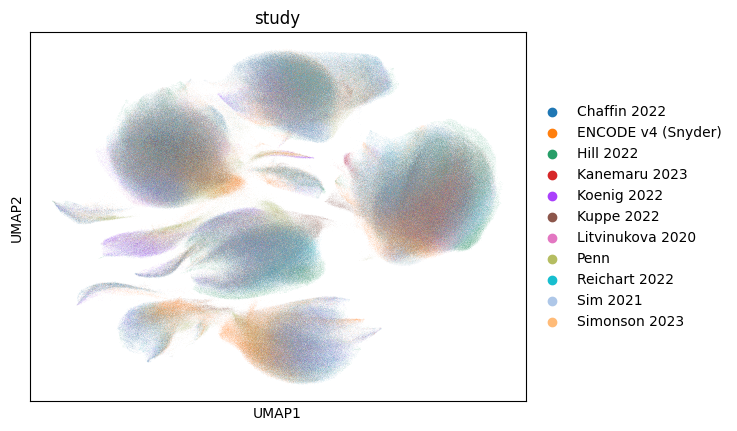

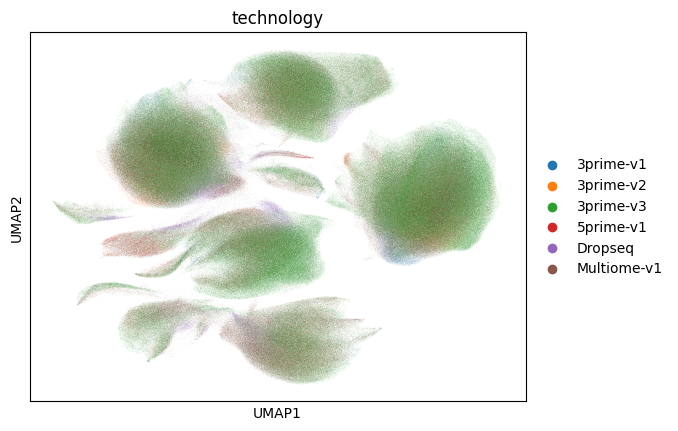

In [7]:
with plt.rc_context():
    sc.pl.umap(adata, color = "technology", show = False)
    plt.savefig(plots_dir + "all_snRNA_UMAP_by_technology.pdf", bbox_inches="tight")
    plt.show()

In [8]:
adata.obs['age_disease_binary'] = adata.obs['age_status'].astype(str) + ":" + adata.obs['disease_binary'].astype(str)

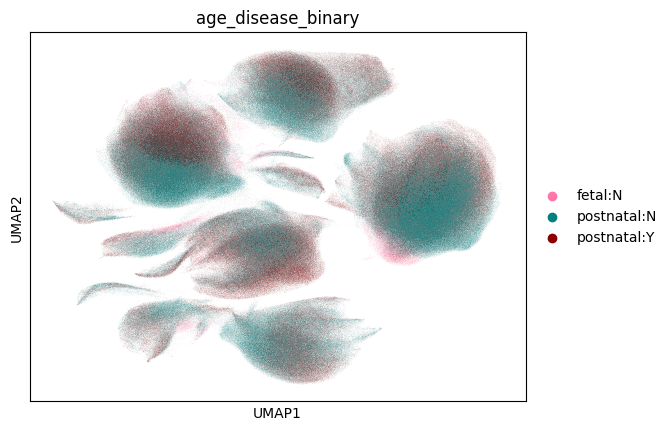

In [9]:
# create UMAP by age + binarized_disease

custom_palette = {
    "fetal:N": "#FF77A9",      # pink  
    "postnatal:N": "#008080",  # teal  
    "postnatal:Y": "#8B0000"   # dark red  
}

with plt.rc_context(): 
    sc.pl.umap(adata, color = ['age_disease_binary'], palette=custom_palette, show=False)
    plt.savefig(plots_dir  + "age_disease_binary.pdf", bbox_inches="tight")
    plt.show()

In [10]:
adata.obs['age_disease'] = adata.obs['age_status'].astype(str) + ":" + adata.obs['disease'].astype(str)

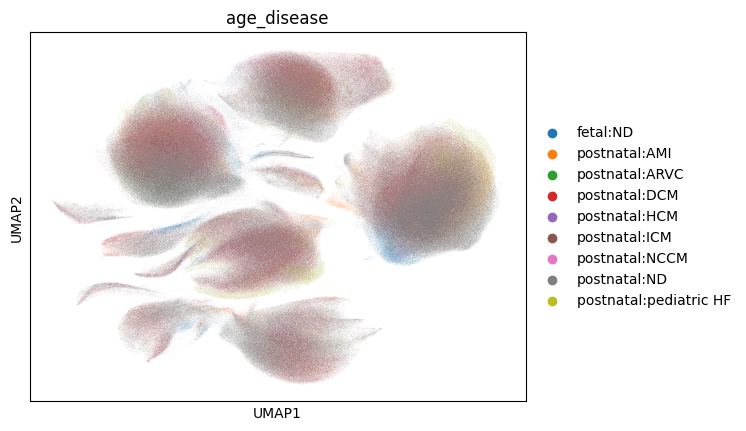

In [11]:
# non-binarized disease
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['age_disease'], show=False)
    plt.savefig(plots_dir  + "age_disease_UMAP.pdf", bbox_inches="tight")
    plt.show()

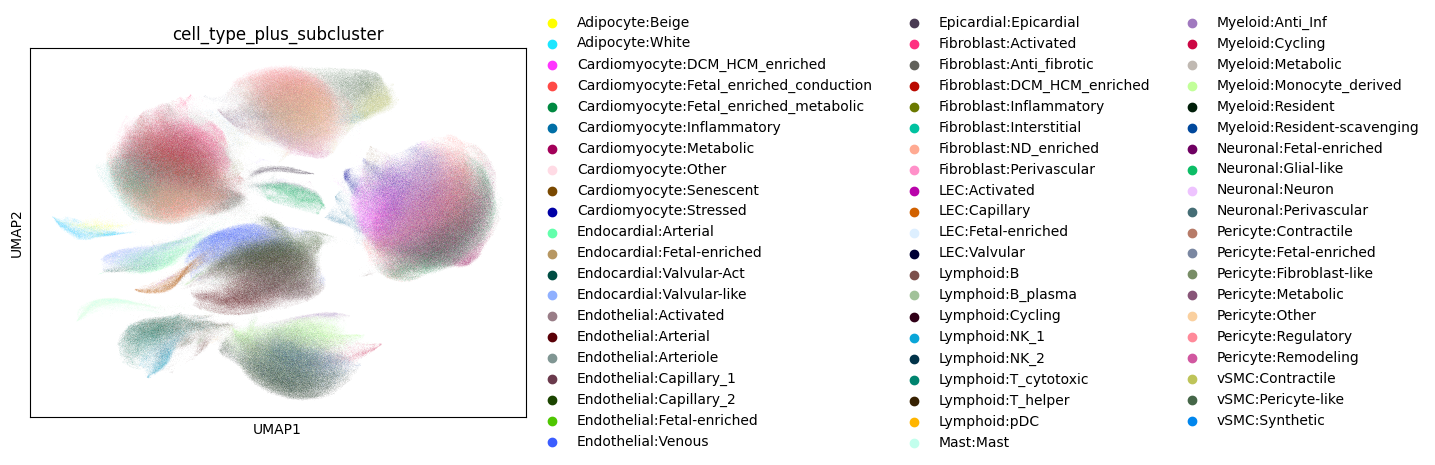

In [20]:
# plot by subcluster
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['cell_type_plus_subcluster'], show=False)
    plt.savefig(plots_dir  + "subcluster_UMAP.pdf", bbox_inches="tight")
    plt.show()

The original and new annotations are highly concordant. In the case of pericytes and vSMCs, some of the papers annotated them as "Mural cells", which we used as "Pericyte" for the "consistent_cell_type" annotation, which may explain why some of the annotations there are discordant.

### Create dotplot for marker gene expression

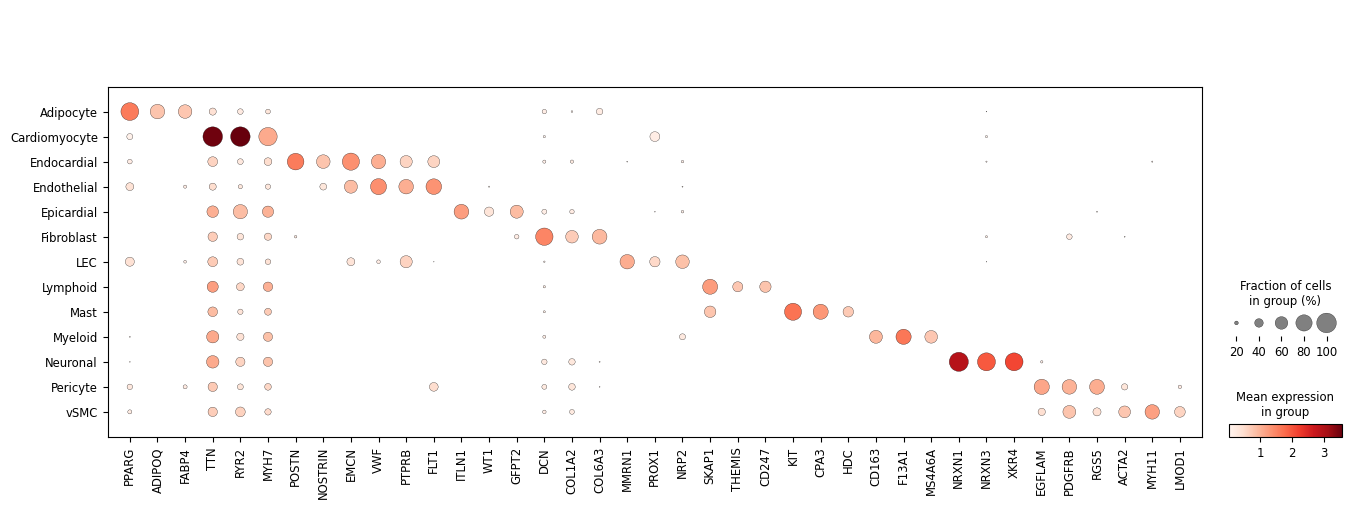

CPU times: user 14.7 s, sys: 7.18 s, total: 21.9 s
Wall time: 21 s


In [21]:
%%time 
marker_genes = ["PPARG", "ADIPOQ", "FABP4",  # Adipocyte
                "TTN", "RYR2", "MYH7",  # Cardiomyocyte
                "POSTN", "NOSTRIN", "EMCN",  # Endocardial
                "VWF", "PTPRB", "FLT1",  # Endothelial
                "ITLN1", "WT1", "GFPT2",  # Epicardial
                "DCN", "COL1A2", "COL6A3", # Fibroblast
                "MMRN1", "PROX1", "NRP2", # LEC
                "SKAP1", "THEMIS", "CD247", # Lymphoid
                "KIT", "CPA3", "HDC",  # Mast
                "CD163", "F13A1", "MS4A6A",  # Myeloid
                "NRXN1", "NRXN3", "XKR4", # Neuronal
                "EGFLAM", "PDGFRB", "RGS5",  # Pericyte
                "ACTA2", "MYH11", "LMOD1"] # vSMC

with plt.rc_context():
    sc.pl.dotplot(adata, var_names = marker_genes, groupby = "final_cell_type", dot_min=0.1, show = False)
    plt.savefig(plots_dir + "snRNA_marker_gene_dotplot.pdf", bbox_inches="tight")
    plt.show()

### Show number of cells per cell type based on disease and postnatal status

In [22]:
adata_metadata = adata.obs

In [24]:
# group by final cell type only
cell_type_df = adata_metadata.groupby(["final_cell_type"]).count().reset_index(drop = False)
cell_type_df = cell_type_df[['final_cell_type', 'age']].rename(columns = {'age': 'count'}).sort_values(by = "count", ascending=False)
# make the cell type a string so that the order isn't fixed
cell_type_df.final_cell_type = cell_type_df.final_cell_type.astype(str)

print(cell_type_df)
print(cell_type_df['count'].sum())

   final_cell_type   count
1    Cardiomyocyte  676654
5       Fibroblast  527364
3      Endothelial  317124
11        Pericyte  281784
9          Myeloid  238446
7         Lymphoid   68889
12            vSMC   59357
2      Endocardial   42582
10        Neuronal   22613
6              LEC   13723
0        Adipocyte   12098
8             Mast    8958
4       Epicardial    5513
2275105


/mnt/data1/william/tmp/ipykernel_1151339/2632652751.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_df = adata_metadata.groupby(["final_cell_type"]).count().reset_index(drop = False)


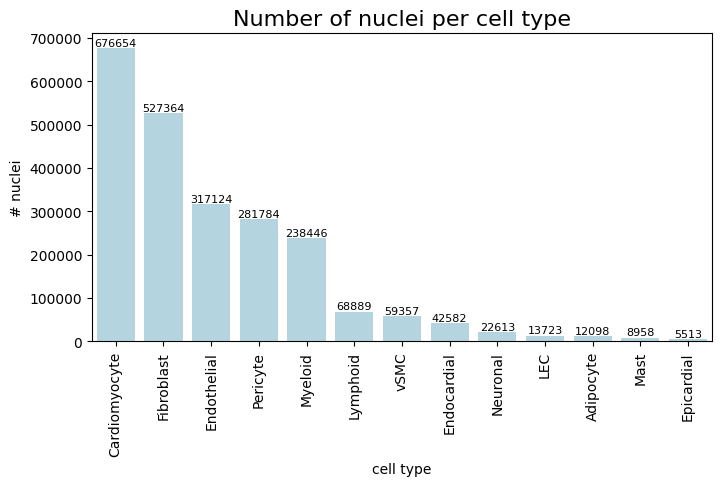

In [32]:
plt.figure(figsize=(8, 4))
sns.barplot(data = cell_type_df, x = 'final_cell_type', y = 'count', color = 'lightblue')

plt.xticks(rotation = 90, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("cell type", fontsize = 10)
plt.ylabel("# nuclei", fontsize = 10)
plt.title("Number of nuclei per cell type", fontsize = 16)

# show values on bar
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2, p.get_height(),                 
        f'{int(p.get_height())}',  ha='center', va='bottom',fontsize=8)

#plt.legend(title='status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(plots_dir + "snRNA_seq_num_cells_per_cell_type.pdf")
plt.show()

### Group also by study

In [37]:
# group by final cell type only
cell_type_df = adata_metadata.groupby(["study"]).count().reset_index(drop = False)
cell_type_df = cell_type_df[['study', 'age']].rename(columns = {'age': 'count'}).sort_values(by = "count", ascending=False)

# make the cell type a string so that the order isn't fixed
cell_type_df.study = cell_type_df.study.astype(str)

print(cell_type_df)

print(cell_type_df['count'].sum())

                 study   count
0         Chaffin 2022  575463
1   ENCODE v4 (Snyder)  469672
8        Reichart 2022  442708
4          Koenig 2022  193959
5           Kuppe 2022  136977
2            Hill 2022  109283
7                 Penn  103927
10       Simonson 2023   94366
6     Litvinukova 2020   81893
9             Sim 2021   40670
3        Kanemaru 2023   26187
2275105


/mnt/data1/william/tmp/ipykernel_1151339/2428814215.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_df = adata_metadata.groupby(["study"]).count().reset_index(drop = False)


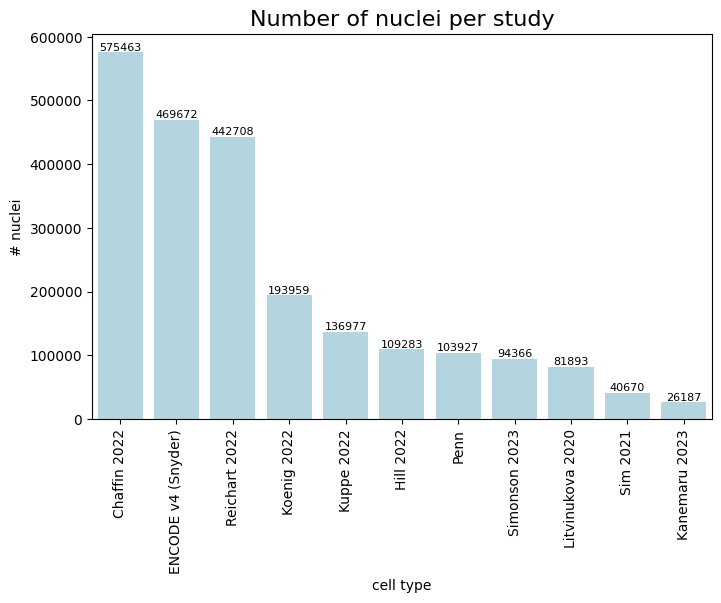

In [39]:
plt.figure(figsize=(8, 5))
sns.barplot(data = cell_type_df, x = 'study', y = 'count', color = 'lightblue')

plt.xticks(rotation = 90, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("cell type", fontsize = 10)
plt.ylabel("# nuclei", fontsize = 10)
plt.title("Number of nuclei per study", fontsize = 16)

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2, p.get_height(),                 
        f'{int(p.get_height())}',  ha='center', va='bottom',fontsize=8)

#plt.legend(title='status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(plots_dir + "snRNA_seq_num_cells_per_study.pdf")
plt.show()